In [2]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Menyiapkan data
np.random.seed(42)
jumlah_pelanggan = 200
lama_berlangganan = np.random.randint(1, 61, jumlah_pelanggan)
penggunaan_bulanan = np.random.randint(1, 101, jumlah_pelanggan)
probabilitas_churn_logit = (100 - lama_berlangganan * 1.5 - penggunaan_bulanan * 0.5 + np.random.normal(0, 20, jumlah_pelanggan))
probabilitas_churn = 1 / (1 + np.exp(-probabilitas_churn_logit / 50))
churn = (probabilitas_churn > 0.5).astype(int)
df = pd.DataFrame({
    'lama_berlangganan': lama_berlangganan,
    'penggunaan_bulanan': penggunaan_bulanan,
    'churn': churn
})

print(df.head())

   lama_berlangganan  penggunaan_bulanan  churn
0                 39                  71      1
1                 52                  59      1
2                 29                  86      1
3                 15                  28      1
4                 43                  66      0


In [3]:
# Membangun model
formula = 'churn ~ lama_berlangganan + penggunaan_bulanan'
model = smf.logit(formula, data=df).fit(disp=0)
print(model.summary())

                           Logit Regression Results                           
Dep. Variable:                  churn   No. Observations:                  200
Model:                          Logit   Df Residuals:                      197
Method:                           MLE   Df Model:                            2
Date:                Wed, 05 Nov 2025   Pseudo R-squ.:                  0.5139
Time:                        12:17:53   Log-Likelihood:                -47.267
converged:                       True   LL-Null:                       -97.245
Covariance Type:            nonrobust   LLR p-value:                 1.972e-22
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             11.8103      1.980      5.964      0.000       7.929      15.692
lama_berlangganan     -0.1699      0.031     -5.436      0.000      -0.231      -0.109
penggunaan_bulanan  

## Landasan Teori & Rumus

In [4]:
odds_ratios = pd.DataFrame({
    "Odds Ratio": np.exp(model.params),
})
print(odds_ratios)

                       Odds Ratio
Intercept           134636.340639
lama_berlangganan        0.843741
penggunaan_bulanan       0.938257


## Uji Kritis #1: Memeriksa Multikolinearitas

In [5]:
X = add_constant(df[['lama_berlangganan', 'penggunaan_bulanan']])
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

              feature       VIF
0               const  7.440194
1   lama_berlangganan  1.005773
2  penggunaan_bulanan  1.005773


## Uji Kritis #2: Memvalidasi Linearitas Logit

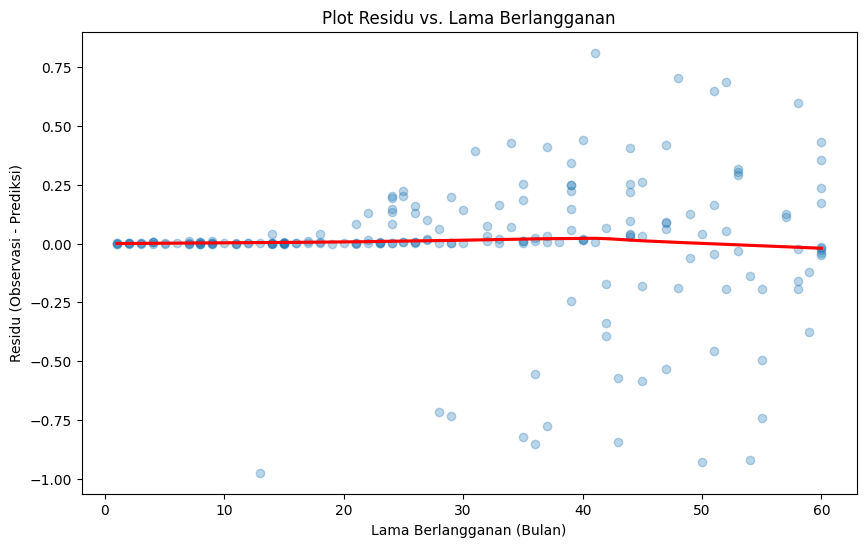

In [8]:
df['prob_pred'] = model.predict(df)
df['resid'] = df['churn'] - df['prob_pred']

plt.figure(figsize=(10, 6))
sns.regplot(x='lama_berlangganan', y='resid', data=df, lowess=True, 
            line_kws={'color': 'red'}, scatter_kws={'alpha': 0.3})
plt.title('Plot Residu vs. Lama Berlangganan')
plt.xlabel('Lama Berlangganan (Bulan)')
plt.ylabel('Residu (Observasi - Prediksi)')
plt.savefig("1.webp", format='webp')

plt.show()

## Jebakan Umum dan Cara Menghindarinya

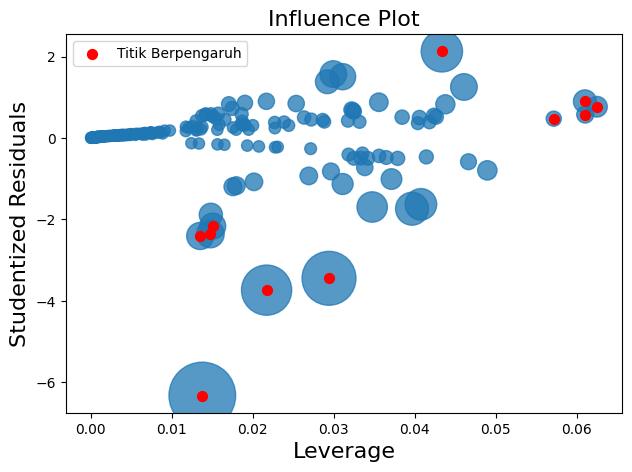

In [18]:
infl = model.get_influence()
x_data = infl.hat_matrix_diag
y_data = infl.resid_studentized


# --- LANGKAH 2: TENTUKAN BATAS (THRESHOLD) ---
threshold_residual = 2.0
threshold_leverage = 0.05

# --- LANGKAH 3: CARI INDEKS TITIK YANG AKAN DITANDAI ---
condition = (np.abs(y_data) > threshold_residual) | (x_data > threshold_leverage)
highlight_indices = np.where(condition)[0]
x_highlight = x_data[highlight_indices]
y_highlight = y_data[highlight_indices]


# --- LANGKAH 4: PLOT DAN HAPUS LABEL) ---
fig = sm.graphics.influence_plot(model, criterion="Cooks", external=False)
ax = fig.get_axes()[0]

# Hapus semua label default 
while ax.texts:
    ax.texts[0].remove()

# --- LANGKAH 5: TAMBAHKAN TANDA/WARNA BARU ---
ax.scatter(x_highlight, y_highlight, color='red', s=50, zorder=10, 
           label='Titik Berpengaruh') # 'label' ini untuk legenda (opsional)
ax.legend()


# --- LANGKAH 6: SIMPAN DAN TAMPILKAN ---
fig.tight_layout(pad=1.0)
plt.savefig("2.webp", format='webp') # Simpan dengan nama baru
plt.show()

## Studi Kasus: Memperbaiki Model Churn yang Kurang Baik

In [15]:
# Menambahkan fitur yang berkorelasi tinggi
df['skor_loyalitas'] = df['lama_berlangganan'] * 2 + np.random.normal(0, 5, jumlah_pelanggan)
X_new = add_constant(df[['lama_berlangganan', 'penggunaan_bulanan', 'skor_loyalitas']])

# Menghitung ulang VIF
vif_new = pd.DataFrame()
vif_new["feature"] = X_new.columns
vif_new["VIF"] = [variance_inflation_factor(X_new.values, i) for i in range(X_new.shape[1])]
print(vif_new)

              feature        VIF
0               const   7.449611
1   lama_berlangganan  45.724634
2  penggunaan_bulanan   1.005905
3      skor_loyalitas  45.707328
